<img src="https://udemedellin.edu.co/wp-content/uploads/2022/10/logo_udemedellin2.png" width="30%">

<b>ESPECIALIZACIÓN EN CIENCIA DE DATOS E INGELIGENCIA ARTIFICIAL</b>

<strong>Fundamentos de Estadística para Ciencia de Datos</strong>

# Sesión 05 — Taller práctico: estadística descriptiva (caso de estudio)

## Objetivos de aprendizaje

Al finalizar este taller serás capaz de:

- Aplicar el flujo completo de estadística descriptiva (tipos de datos, calidad de datos, descriptiva cualitativa y cuantitativa) sobre un caso real, integrando lo visto en las sesiones 1 a 4.
- Tomar y justificar decisiones de limpieza de datos (faltantes) según el contexto de cada variable, incluyendo cuándo la ausencia de un dato puede ser informativa y no aleatoria.
- Construir variables derivadas (*feature engineering*) cuando aportan una señal que las variables originales no dan por separado.
- Detectar y tratar atípicos (no solo detectarlos): comparar recorte (*capping*) contra transformación logarítmica según el objetivo del análisis.
- Describir variables cualitativas y cuantitativas, y relacionarlas con una variable target de negocio, sin extrapolar más allá de lo que los datos permiten.

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", palette="deep")
%matplotlib inline

pd.set_option("display.precision", 3)

## 1. Planteamiento del caso y carga de datos

**Contexto:** 

Eres analista de riesgo en una entidad financiera. El equipo de crédito quiere entender qué caracteriza a las solicitudes de préstamo aprobadas frente a las rechazadas, antes de construir cualquier modelo de aprobación.

**Objetivo del taller:** 

Revisar el dataset `loan` para explorarlo, limpiarlo y describirlo, identificando qué caracteriza a las solicitudes según su estado de aprobación, como insumo para decisiones posteriores. No se construye ningún modelo ni prueba de hipótesis en este taller.

**Fuente:** 

Dataset "Loan Prediction Practice Problem III", una competencia práctica de **Analytics Vidhya**. Cargamos el dataset completo (614 solicitudes en train, 367 en test) desde un mirror en GitHub con acceso directo por URL.

In [2]:
loan = pd.read_csv("https://raw.githubusercontent.com/sahutkarsh/loan-prediction-analytics-vidhya/master/train.csv")
loan["Loan_Status"] = loan["Loan_Status"].map({"Y": 1, "N": 0})
print(f"Filas: {loan.shape[0]}")
print(f"Columnas: {loan.shape[1]}")
loan.head()

Filas: 614
Columnas: 13


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,1
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1


In [3]:
loan.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status
count,614.000,614.000,592.000,600.00,564.000,614.000
mean,5403.459,1621.246,146.412,342.00,0.842,0.687
std,6109.042,2926.248,85.587,65.12,0.365,0.464
min,150.000,0.000,9.000,12.00,0.000,0.000
25%,2877.500,0.000,100.000,360.00,1.000,0.000
50%,3812.500,1188.500,128.000,360.00,1.000,1.000
75%,5795.000,2297.250,168.000,360.00,1.000,1.000
max,81000.000,41667.000,700.000,480.00,1.000,1.000


In [4]:
loan.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    int64  
dtypes: float64(4), int64(2), str(7)
memory usage: 62.5 KB


### Diccionario de datos

Este es el diccionario del dataset original "Loan Prediction Practice Problem III" (Analytics Vidhya).

| Variable | Significado |
|---|---|
| `Loan_ID` | ID único de la solicitud |
| `Gender` | Género del solicitante |
| `Married` | Estado civil del solicitante (casado/no) |
| `Dependents` | Número de dependientes económicos |
| `Education` | Nivel educativo (Graduate / Not Graduate) |
| `Self_Employed` | Si el solicitante es independiente |
| `ApplicantIncome` | Ingreso mensual del solicitante |
| `CoapplicantIncome` | Ingreso mensual del coaplicante (0 si no hay) |
| `LoanAmount` | Monto del préstamo solicitado, en miles |
| `Loan_Amount_Term` | Plazo del préstamo, en meses |
| `Credit_History` | Si el historial crediticio cumple los criterios del banco (1) o no (0) |
| `Property_Area` | Zona del inmueble (Urban / Semiurban / Rural) |
| `Loan_Status` | Si el préstamo fue aprobado (Y/N, aquí 1/0) — **variable target** |

### Clasificación de variables

Antes de describir nada, clasificamos cada columna según la taxonomía de la sesión 1:

| Variable | Tipo | Subtipo |
|---|---|---|
| `Loan_ID` | Identificador | No es una variable analítica, es una clave única por solicitud |
| `Gender`, `Married`, `Education`, `Self_Employed`, `Property_Area` | Cualitativa | Nominal |
| `Dependents` | Cualitativa | Ordinal — en el fondo es un conteo, pero el valor `"3+"` agrupa "3 o más" en una sola categoría abierta, así que se trata como ordinal en vez de forzarla a numérica |
| `ApplicantIncome`, `CoapplicantIncome`, `LoanAmount` | Cuantitativa | Continua (razón) |
| `Loan_Amount_Term` | Cuantitativa | Discreta (plazo en meses, toma pocos valores repetidos) |
| `Credit_History` | Cuantitativa (codificada 0/1) | En la práctica funciona como cualitativa binaria: 1 = tiene historial crediticio que cumple los criterios del banco, 0 = no lo cumple |
| `Loan_Status` | Cualitativa | Nominal binaria — **variable target de este taller** (1 = aprobado, 0 = rechazado) |

`Loan_ID` no aporta información analítica (es una clave única por fila, cardinalidad = número de filas), así que se descarta antes de cualquier análisis.

In [5]:
loan = loan.drop(columns="Loan_ID")

## 2. Calidad de datos: valores faltantes

Este dataset tiene un problema de calidad y ausencia de datos. Antes de imputar, conviene revisar si esa ausencia está relacionada con la target, si lo está, imputar a la ligera puede introducir sesgo.

In [6]:
loan.isna().sum()

Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

Siete columnas tienen datos faltantes, con volúmenes muy distintos: `Credit_History` (50 filas, ~8%) es la más afectada, seguida de `Self_Employed` (32), `LoanAmount` (22), `Loan_Amount_Term` (14), `Dependents` (15), `Gender` (13) y `Married` (3).

`Credit_History` es, además, la variable con mayor relación aparente con `Loan_Status`, así que antes de imputarla vale la pena revisar si las filas donde falta se comportan distinto al resto.

In [7]:
print("Tasa de aprobación general:", loan['Loan_Status'].mean().round(3))

Tasa de aprobación general: 0.687


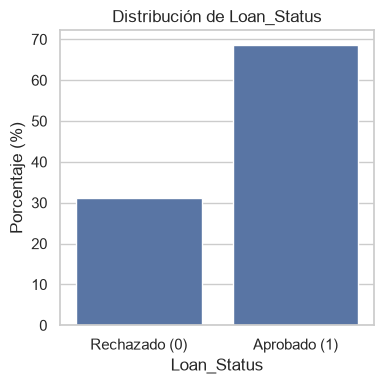

In [8]:
fig, ax = plt.subplots(figsize=(4, 4))
sns.countplot(x=loan["Loan_Status"], stat="percent", ax=ax)
ax.set_title("Distribución de Loan_Status")
ax.set_xticks([0, 1])
ax.set_xticklabels(["Rechazado (0)", "Aprobado (1)"])
ax.set_ylabel("Porcentaje (%)")
plt.tight_layout()
plt.show()

In [9]:
print("Tasa de aprobación por categoría de Credit_History:")
loan.groupby(by="Credit_History", as_index=False).agg({"Loan_Status": ['count', 'mean']})


Tasa de aprobación por categoría de Credit_History:


Credit_History Loan_Status       
                       count   mean
0            0.0          89  0.079
1            1.0         475  0.796

In [10]:
print("Tasa de aprobación cuando Credit_History es NaN:")
loan.loc[loan["Credit_History"].isna(), "Loan_Status"].mean().round(3)

Tasa de aprobación cuando Credit_History es NaN:


np.float64(0.74)

La tasa de aprobación es ~79.6% cuando `Credit_History == 1`, ~7.9% cuando `Credit_History == 0`, y ~74.0% cuando falta — mucho más cercana al grupo con historial en regla que al grupo sin él. Esto sugiere que la ausencia de esta variable no está sistemáticamente asociada a solicitudes rechazadas, y que **imputar con la moda (1) es una decisión defendible**, no una arbitrariedad: la evidencia respalda que el subgrupo con dato faltante se comporta más como el grupo mayoritario.

In [11]:
loan["Dependents"].value_counts()

Dependents
0     345
1     102
2     101
3+     51
Name: count, dtype: int64

`Dependents` tiene una categoría abierta, `"3+"`, que agrupa "3 o más" — la dejamos como categórica ordinal (no se convierte a numérica) porque ninguna comparación de este taller necesita operar con ella aritméticamente; imputar la moda funciona igual de bien sobre texto que sobre un número.

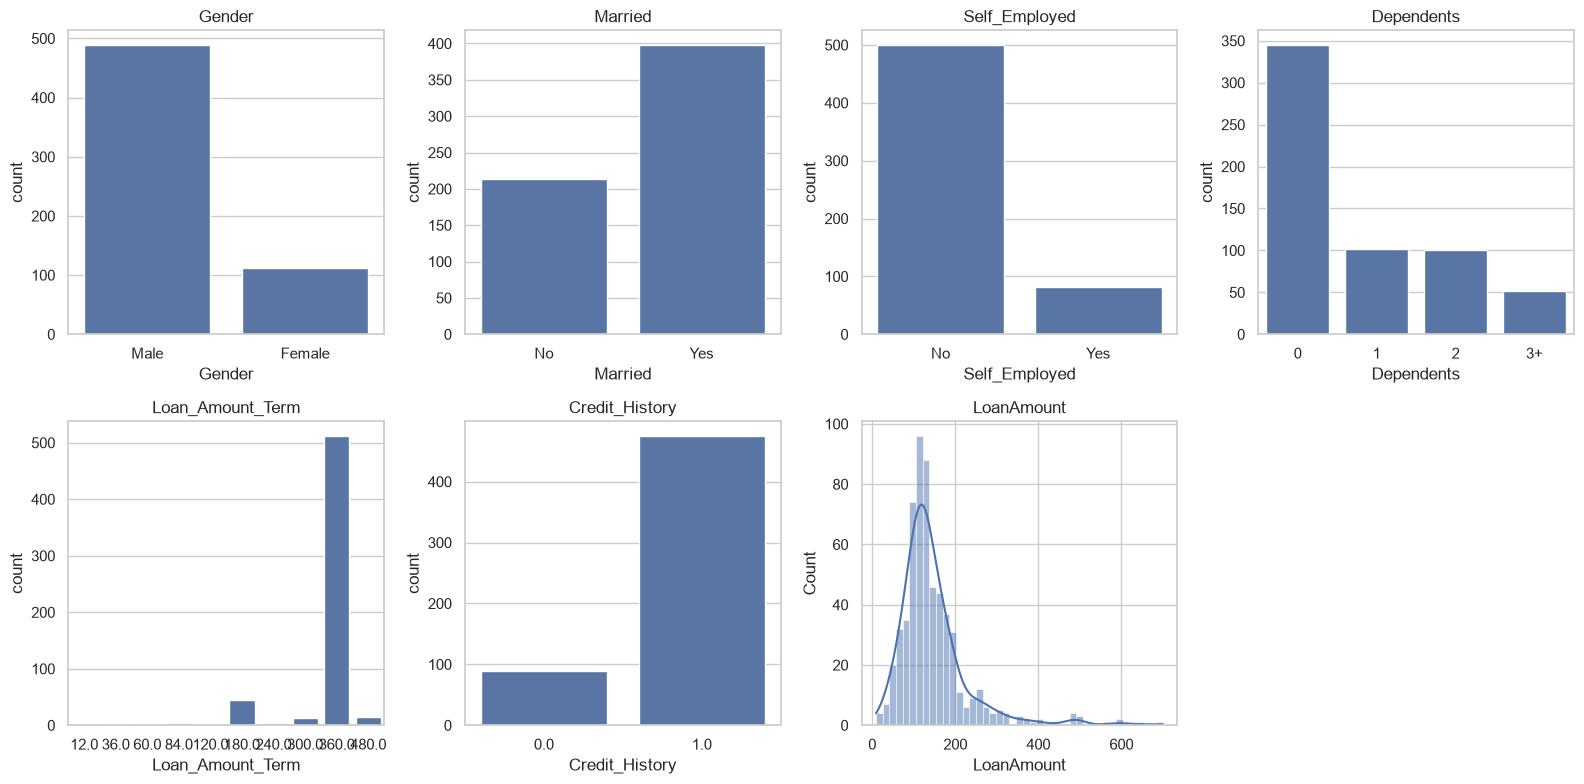

In [12]:
categorical_na_columns = ["Gender", "Married", "Self_Employed", "Dependents", "Loan_Amount_Term", "Credit_History"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, column in zip(axes, categorical_na_columns):
    sns.countplot(x=loan[column], ax=ax)
    ax.set_title(column)

sns.histplot(loan["LoanAmount"], kde=True, ax=axes[6])
axes[6].set_title("LoanAmount")

axes[7].axis("off")

plt.tight_layout()
plt.show()

In [13]:
loan["Loan_Amount_Term"].value_counts()

Loan_Amount_Term
360.0    512
180.0     44
480.0     15
300.0     13
240.0      4
84.0       4
120.0      3
60.0       2
36.0       2
12.0       1
Name: count, dtype: int64

In [14]:
clean_loan = loan.copy()

# Gender, Married, Self_Employed, Dependents, Loan_Amount_Term, Credit_History:
# faltantes de bajo volumen o sin relación aparente con el target -> imputar con la moda
categorical_impute_columns = ["Gender", "Married", "Self_Employed", "Dependents", "Loan_Amount_Term", "Credit_History"]
for column in categorical_impute_columns:
    mode = clean_loan[column].mode()[0]
    clean_loan[column] = clean_loan[column].fillna(mode)

# LoanAmount: numérica y sesgada -> la mediana es más robusta que la media para imputar
clean_loan["LoanAmount"] = clean_loan["LoanAmount"].fillna(clean_loan["LoanAmount"].median())

print(f"Valores faltantes restantes: {clean_loan.isna().sum().sum()}")

Valores faltantes restantes: 0


## 3. Feature engineering

Con los datos limpios, construimos dos variables derivadas que tienen sentido de negocio directo en evaluación de riesgo crediticio, cada una responde a una pregunta que las variables originales no responden solas:

- **`TotalIncome`**: la capacidad real de pago depende del ingreso del hogar, no solo del solicitante. Además, resuelve un caso que `ApplicantIncome` solo no captura: el 44.5% de los coaplicantes tiene `CoapplicantIncome == 0` (aplicación individual, sin ingreso adicional que sumar).
- **`LoanAmount_to_Income`**: la carga de deuda relativa al ingreso, el mismo tipo de métrica que usan las entidades de crédito para decidir aprobación, y potencialmente más informativa que el monto del préstamo o el ingreso por separado. **Nota de unidades:** según el diccionario de datos, `LoanAmount` está expresado en miles mientras que `ApplicantIncome`/`CoapplicantIncome` no, dividirlas directamente mezclaría escalas distintas. Por eso multiplicamos `LoanAmount` por 1000 antes de dividir, dejando el ratio en una escala interpretable: aproximadamente cuántos meses de ingreso representa el monto del préstamo.

In [15]:
clean_loan["TotalIncome"] = clean_loan["ApplicantIncome"] + clean_loan["CoapplicantIncome"]
# LoanAmount está en miles (ver diccionario de datos); se multiplica por 1000 para que quede
# en la misma escala que TotalIncome antes de dividir
clean_loan["LoanAmount_to_Income"] = (clean_loan["LoanAmount"] * 1000) / clean_loan["TotalIncome"]

clean_loan[["ApplicantIncome", "CoapplicantIncome", "TotalIncome", "LoanAmount", "LoanAmount_to_Income"]].head()

,ApplicantIncome,CoapplicantIncome,TotalIncome,LoanAmount,LoanAmount_to_Income
0,5849,0.0,5849.0,128.0,21.884
1,4583,1508.0,6091.0,128.0,21.015
2,3000,0.0,3000.0,66.0,22.000
3,2583,2358.0,4941.0,120.0,24.287
4,6000,0.0,6000.0,141.0,23.500


## 4. Descriptiva de variables cualitativas

Empezamos por las variables categóricas: `Gender`, `Married`, `Education`, `Property_Area`, `Self_Employed`, `Credit_History` y `Dependents`, relacionándolas con `Loan_Status` (nuestro target).

In [16]:
gender_table = clean_loan["Gender"].value_counts().to_frame(name="FA")
gender_table["FR"] = gender_table["FA"] / len(clean_loan)
gender_table["Porcentaje (%)"] = gender_table["FR"] * 100
gender_table

,FA,FR,Porcentaje (%)
Gender,,,
Male,502,0.818,81.759
Female,112,0.182,18.241


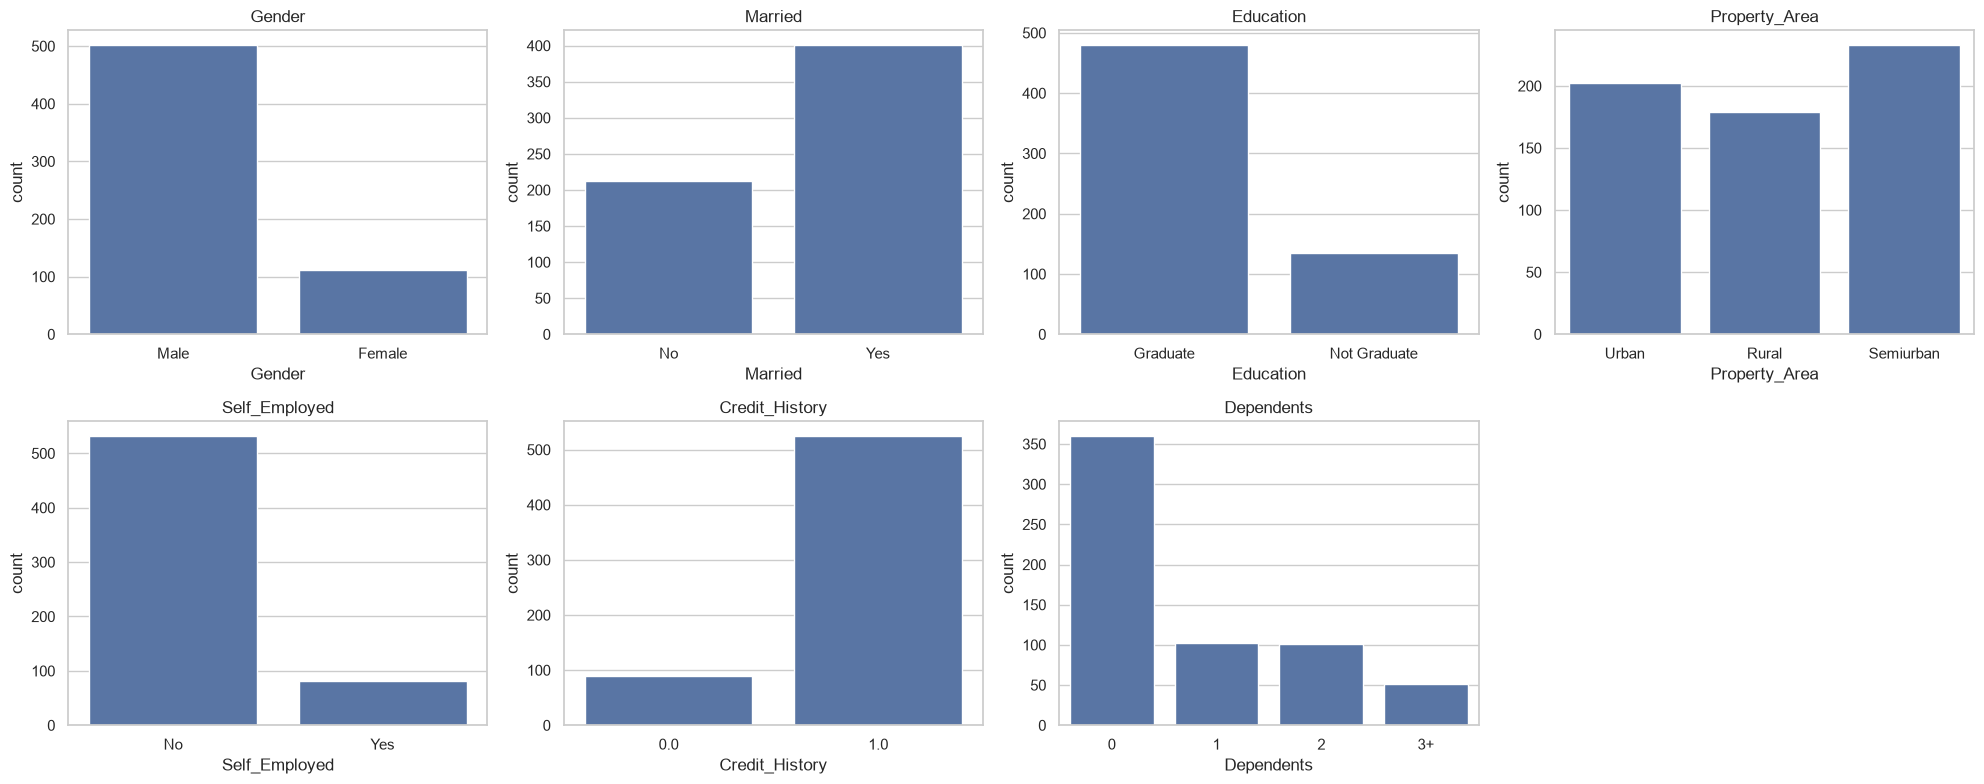

In [17]:
categorical_columns = ["Gender", "Married", "Education", "Property_Area", "Self_Employed", "Credit_History", "Dependents"]
dependents_order = ["0", "1", "2", "3+"]
credit_history_order = [0.0, 1.0]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for ax, column in zip(axes, categorical_columns):
    if column == "Dependents":
        order = dependents_order
    elif column == "Credit_History":
        order = credit_history_order
    else:
        order = None
    sns.countplot(x=clean_loan[column], order=order, ax=ax)
    ax.set_title(column)

axes[7].axis("off")
plt.tight_layout()
plt.show()

In [18]:
for column in categorical_columns:
    print(f"--- {column} x Loan_Status (normalizado por fila, %) ---")
    print((pd.crosstab(clean_loan[column], clean_loan["Loan_Status"], normalize="index") * 100).round(1))
    print()

--- Gender x Loan_Status (normalizado por fila, %) ---
Loan_Status     0     1
Gender                 
Female       33.0  67.0
Male         30.9  69.1

--- Married x Loan_Status (normalizado por fila, %) ---
Loan_Status     0     1
Married                
No           37.1  62.9
Yes          28.2  71.8

--- Education x Loan_Status (normalizado por fila, %) ---
Loan_Status      0     1
Education               
Graduate      29.2  70.8
Not Graduate  38.8  61.2

--- Property_Area x Loan_Status (normalizado por fila, %) ---
Loan_Status       0     1
Property_Area            
Rural          38.5  61.5
Semiurban      23.2  76.8
Urban          34.2  65.8

--- Self_Employed x Loan_Status (normalizado por fila, %) ---
Loan_Status       0     1
Self_Employed            
No             31.2  68.8
Yes            31.7  68.3

--- Credit_History x Loan_Status (normalizado por fila, %) ---
Loan_Status        0     1
Credit_History            
0.0             92.1   7.9
1.0             21.0  79.0

--- 

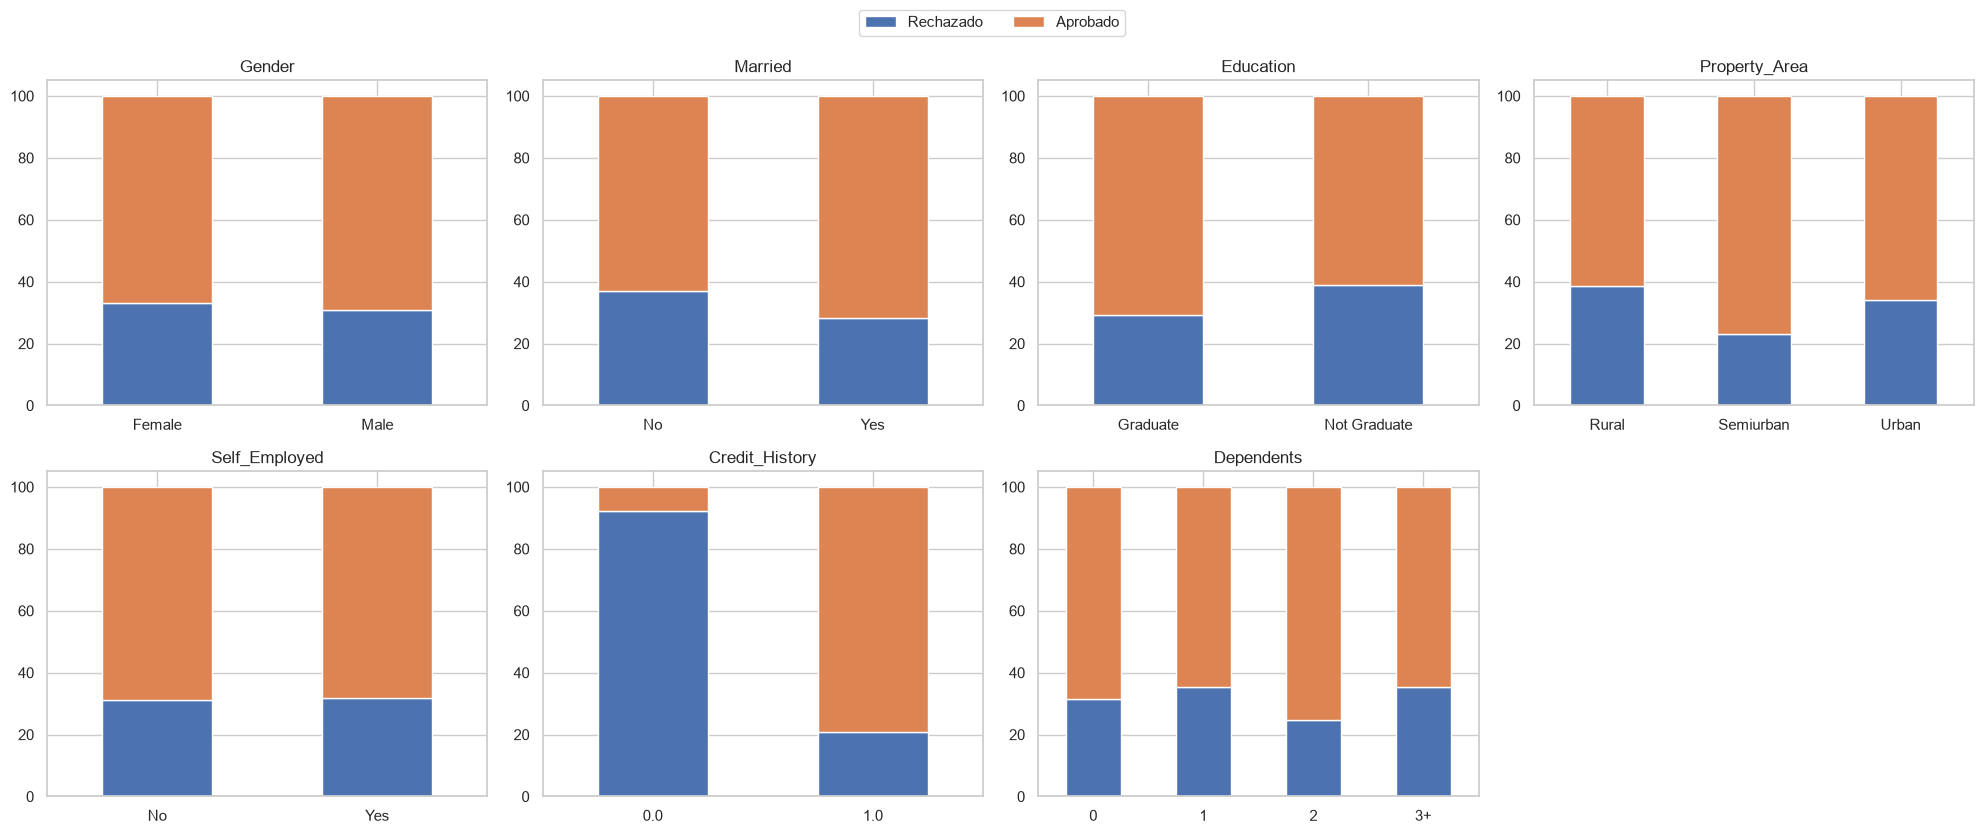

In [19]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for ax, column in zip(axes, categorical_columns):
    if column == "Dependents":
        order = dependents_order
    elif column == "Credit_History":
        order = credit_history_order
    else:
        order = None
    composition = pd.crosstab(clean_loan[column], clean_loan["Loan_Status"], normalize="index") * 100
    if order:
        composition = composition.reindex(order)
    composition.columns = ["Rechazado", "Aprobado"]
    composition.plot(kind="bar", stacked=True, ax=ax, legend=False)
    ax.set_title(column)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)

axes[7].axis("off")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.05))
plt.tight_layout()
plt.show()

La tasa de aprobación general es ~68.7%. Por categoría: `Married == "Yes"` aprueba más (~71.8%) que `"No"` (~62.9%); `Property_Area == "Semiurban"` aprueba más (~76.8%) que `"Rural"` (~61.5%); `Education == "Graduate"` aprueba algo más (~70.8%) que `"Not Graduate"` (~61.2%); `Gender` muestra una diferencia menor (Male ~69.1% vs. Female ~67.0%, con solo 112 mujeres en la muestra). `Self_Employed` prácticamente no distingue nada (~68.8% vs. ~68.3%), la diferencia más chica de todas las variables cualitativas. `Dependents` no muestra un patrón monótono: `2` aprueba más que el resto (~75.2%), mientras `0` (~68.6%) queda cerca de la tasa general y `1`/`3+` quedan algo por debajo (ambos ~64.7%) — no hay una relación clara de "a más dependientes, menos aprobación". `Credit_History` es la única que se sale de la escala del resto: ~79.0% de aprobación cuando vale 1, frente a ~7.9% cuando vale 0 — una brecha de ~71 puntos porcentuales (la analizamos en detalle en la sección 7, junto con las variables cuantitativas). Fuera de `Credit_History`, ninguna diferencia es enorme — son candidatas a revisar, no conclusiones.

## 5. Descriptiva de variables cuantitativas

Usamos `ApplicantIncome` como variable "hilo conductor" de esta sección.

In [20]:
clean_loan["ApplicantIncome"].describe()

count      614.000
mean      5403.459
std       6109.042
min        150.000
25%       2877.500
50%       3812.500
75%       5795.000
max      81000.000
Name: ApplicantIncome, dtype: float64

In [21]:
income = clean_loan["ApplicantIncome"]

mean_income = income.mean()
median_income = income.median()
std_income = income.std(ddof=1)
cv_income = std_income / mean_income * 100
q1, q3 = income.quantile([0.25, 0.75])
iqr = q3 - q1

print(f"Media: {mean_income:.0f}")
print(f"Mediana: {median_income:.0f}")
print(f"Desviación estándar: {std_income:.0f}")
print(f"Coeficiente de variación: {cv_income:.1f}%")
print(f"Q1: {q1:.0f}, Q3: {q3:.0f}, IQR: {iqr:.0f}")

Media: 5403
Mediana: 3812
Desviación estándar: 6109
Coeficiente de variación: 113.1%
Q1: 2878, Q3: 5795, IQR: 2918


La media (~5,403) es mucho mayor que la mediana (~3,813) y el coeficiente de variación es altísimo (~113%): un primer indicio de una asimetría a la derecha muy marcada.

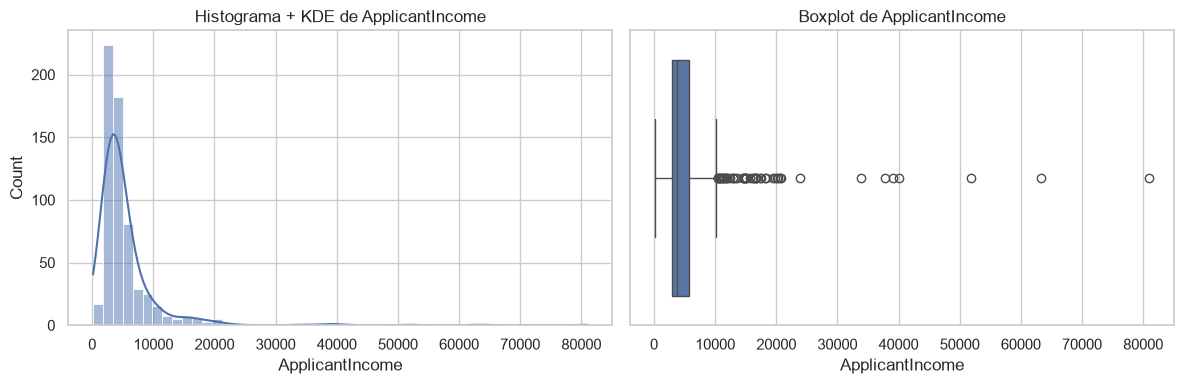

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(income, kde=True, ax=axes[0])
axes[0].set_title("Histograma + KDE de ApplicantIncome")
sns.boxplot(x=income, ax=axes[1])
axes[1].set_title("Boxplot de ApplicantIncome")
plt.tight_layout()
plt.show()

### Evaluación de normalidad de `ApplicantIncome`

Asimetría: 6.52
Curtosis (exceso): 60.04
Shapiro-Wilk p-valor: 4.81e-39


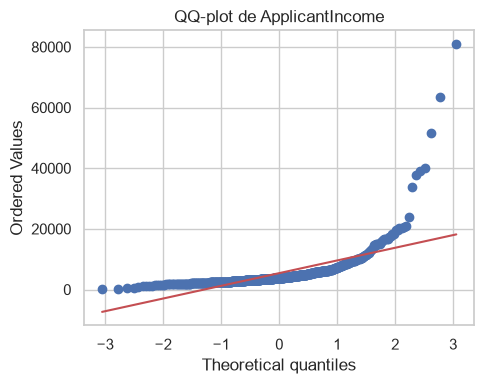

In [23]:
income_skew = stats.skew(income)
income_kurtosis = stats.kurtosis(income)
_, income_p_value = stats.shapiro(income)

print(f"Asimetría: {income_skew:.2f}")
print(f"Curtosis (exceso): {income_kurtosis:.2f}")
print(f"Shapiro-Wilk p-valor: {income_p_value:.2e}")

fig, ax = plt.subplots(figsize=(5, 4))
stats.probplot(income, dist="norm", plot=ax)
ax.set_title("QQ-plot de ApplicantIncome")
plt.tight_layout()
plt.show()

Una asimetría de ~6.5 es extrema, y la curtosis (~60) confirma colas mucho más pesadas que una normal. Shapiro-Wilk rechaza normalidad con un p-valor prácticamente nulo. El QQ-plot muestra un puñado de puntos muy alejados de la línea de normalidad en la cola superior: unos pocos solicitantes con ingresos extremadamente altos frente al resto.

### Vistazo rápido a las demás variables cuantitativas

`ApplicantIncome` fue el hilo conductor, pero el dataset tiene tres numéricas originales más (`CoapplicantIncome`, `LoanAmount`, `Loan_Amount_Term`) y las dos derivadas en la sección 3 (`TotalIncome`, `LoanAmount_to_Income`).

In [24]:
other_quant_columns = ["CoapplicantIncome", "LoanAmount", "Loan_Amount_Term", "TotalIncome", "LoanAmount_to_Income"]
clean_loan[other_quant_columns].describe()

,CoapplicantIncome,LoanAmount,Loan_Amount_Term,TotalIncome,LoanAmount_to_Income
count,614.000,614.000,614.000,614.000,614.000
mean,1621.246,145.752,342.410,7024.705,23.877
std,2926.248,84.107,64.429,6458.664,8.707
min,0.000,9.000,12.000,1442.000,2.523
25%,0.000,100.250,360.000,4166.000,19.221
50%,1188.500,128.000,360.000,5416.500,24.129
75%,2297.250,164.750,360.000,7521.750,28.158
max,41667.000,700.000,480.000,81000.000,82.712


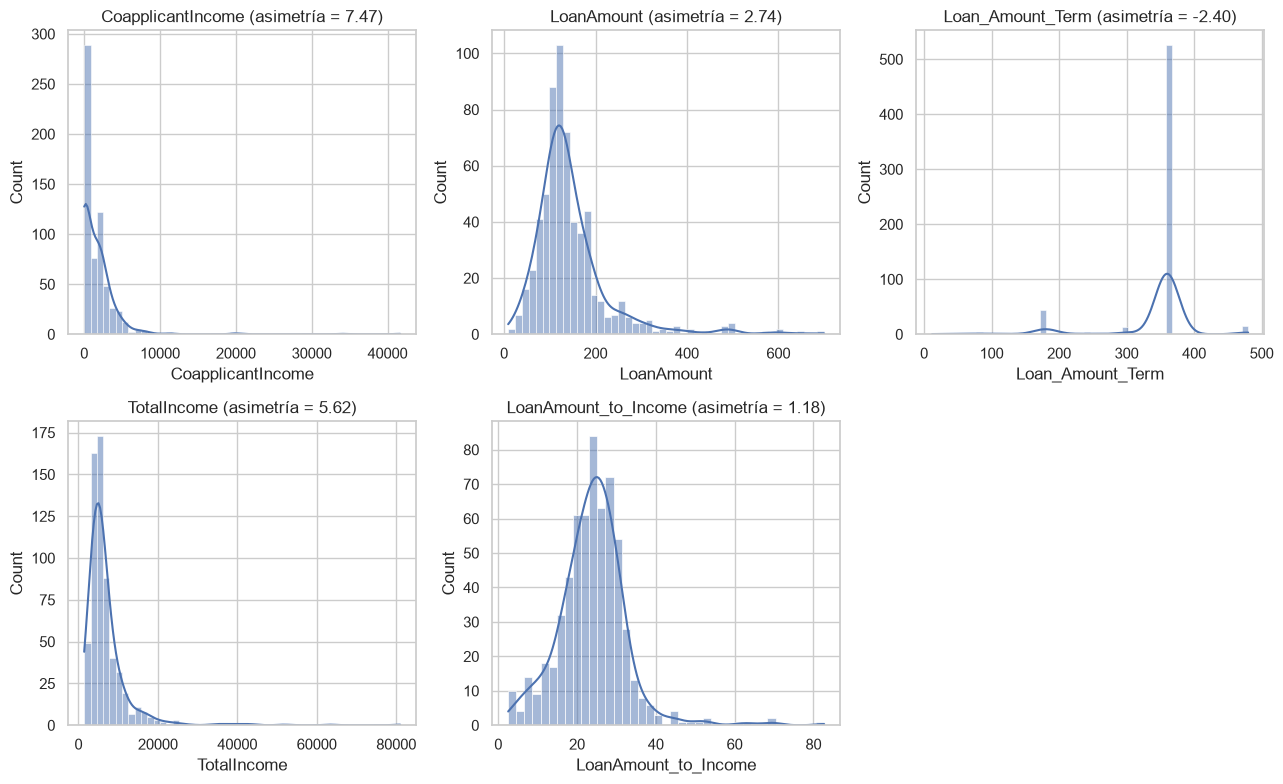

CoapplicantIncome == 0: 44.5% de las solicitudes


In [25]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.flatten()
for ax, column in zip(axes, other_quant_columns):
    sns.histplot(clean_loan[column], kde=True, ax=ax)
    ax.set_title(f"{column} (asimetría = {stats.skew(clean_loan[column]):.2f})")
axes[5].axis("off")
plt.tight_layout()
plt.show()

print(f"CoapplicantIncome == 0: {(clean_loan['CoapplicantIncome'] == 0).mean():.1%} de las solicitudes")

`CoapplicantIncome` es la más sesgada de las tres originales (asimetría ~7.5, incluso más que `ApplicantIncome`), pero por una razón distinta a la de un puñado de ingresos altos: el 44.5% de las solicitudes tiene `CoapplicantIncome == 0` (aplicación individual, sin coaplicante). Con el 50% central de los datos concentrado en gran parte en 0 (Q1 = 0), la regla del IQR no aplica bien aquí (marcaría como atípico cualquier valor positivo, por pequeño que sea) — no se trata como candidata a capping/log en la sección 6.

`LoanAmount` tiene una asimetría moderada (~2.74) — sí es candidata razonable para la regla del IQR, y la tratamos junto con `ApplicantIncome` en la siguiente sección.

`Loan_Amount_Term` es la única con asimetría **negativa** (~-2.40): no por una cola de valores muy bajos, sino porque el 85.7% de los préstamos comparte el mismo plazo (360 meses, visto en la sección 2), con una cola corta hacia plazos más cortos. Es una variable discreta dominada por un valor administrativo estándar, no una medida continua de variabilidad individual — no tiene sentido aplicarle capping o transformación log.

De las dos derivadas, `TotalIncome` sigue muy sesgada (~5.62) — hereda el mismo patrón de `ApplicantIncome`, sumarle `CoapplicantIncome` no lo corrige. `LoanAmount_to_Income`, en cambio, es la variable cuantitativa menos sesgada de todo el taller (~1.18): al ser un cociente, atenúa parcialmente el efecto de los ingresos extremos que dominan tanto a `ApplicantIncome` como a `TotalIncome` por separado — un beneficio adicional del feature engineering que no habíamos anticipado al construirla en la sección 3.

In [26]:
clean_loan['LoanAmount_to_Income'].mean(), clean_loan['LoanAmount_to_Income'].median()

(np.float64(23.87678674779447), np.float64(24.12920896847402))

## 6. Tratamiento de atípicos

Hasta ahora solo detectamos atípicos (regla del IQR, como en sesiones anteriores). Aquí vamos un paso más allá: **¿qué hacer con ellos?** Eliminarlos no es defendible — son solicitantes reales con ingresos altos, y borrarlos sesgaría la muestra hacia ingresos bajos, justo cuando el objetivo es describir a todos los solicitantes por igual. Nos enfocamos en `ApplicantIncome` y `LoanAmount`; `CoapplicantIncome` y `Loan_Amount_Term` quedan fuera por lo visto en la sección anterior (Q1 = 0 en la primera, variable administrativa discreta en la segunda).

In [27]:
for column in ["ApplicantIncome", "LoanAmount"]:
    series = clean_loan[column]
    q1_c, q3_c = series.quantile([0.25, 0.75])
    iqr_c = q3_c - q1_c
    upper_limit = q3_c + 1.5 * iqr_c
    n_outliers = (series > upper_limit).sum()
    print(f"{column}: límite superior = {upper_limit:.0f}, atípicos = {n_outliers} ({n_outliers / len(series):.1%}), máximo = {series.max():.0f}")

ApplicantIncome: límite superior = 10171, atípicos = 50 (8.1%), máximo = 81000
LoanAmount: límite superior = 262, atípicos = 41 (6.7%), máximo = 700


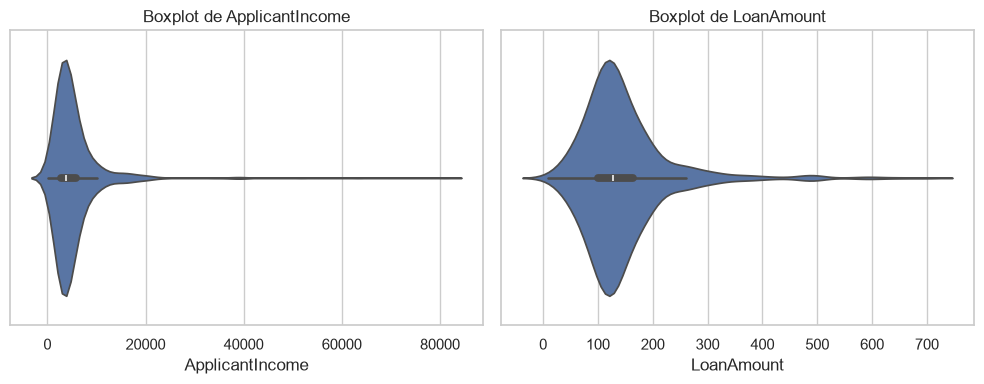

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, column in zip(axes, ["ApplicantIncome", "LoanAmount"]):
    sns.violinplot(x=clean_loan[column], ax=ax)
    ax.set_title(f"Boxplot de {column}")
plt.tight_layout()
plt.show()

`ApplicantIncome` tiene 50 atípicos (8.1%, máximo 81,000 frente a un límite de ~10,171) y `LoanAmount` tiene 41 (6.7%, máximo 700 frente a un límite de 262). Volúmenes demasiado grandes para ignorar, y demasiado reales para eliminar.

In [29]:
q1_income, q3_income = income.quantile([0.25, 0.75])
iqr_income = q3_income - q1_income
upper_income = q3_income + 1.5 * iqr_income

q1_loan, q3_loan = clean_loan["LoanAmount"].quantile([0.25, 0.75])
iqr_loan = q3_loan - q1_loan
upper_loan = q3_loan + 1.5 * iqr_loan

# Capping/winsorizing: recorta al límite superior del IQR, conserva la fila y las unidades originales
clean_loan["ApplicantIncome_capped"] = income.clip(upper=upper_income)
clean_loan["LoanAmount_capped"] = clean_loan["LoanAmount"].clip(upper=upper_loan)

# Alternativa: transformación logarítmica (ya vista en sesión 3)
income_log = np.log1p(income)

print(f"Asimetría original: {stats.skew(income):.2f}")
print(f"Asimetría con capping: {stats.skew(clean_loan['ApplicantIncome_capped']):.2f}")
print(f"Asimetría con log: {stats.skew(income_log):.2f}")

Asimetría original: 6.52
Asimetría con capping: 1.04
Asimetría con log: 0.48


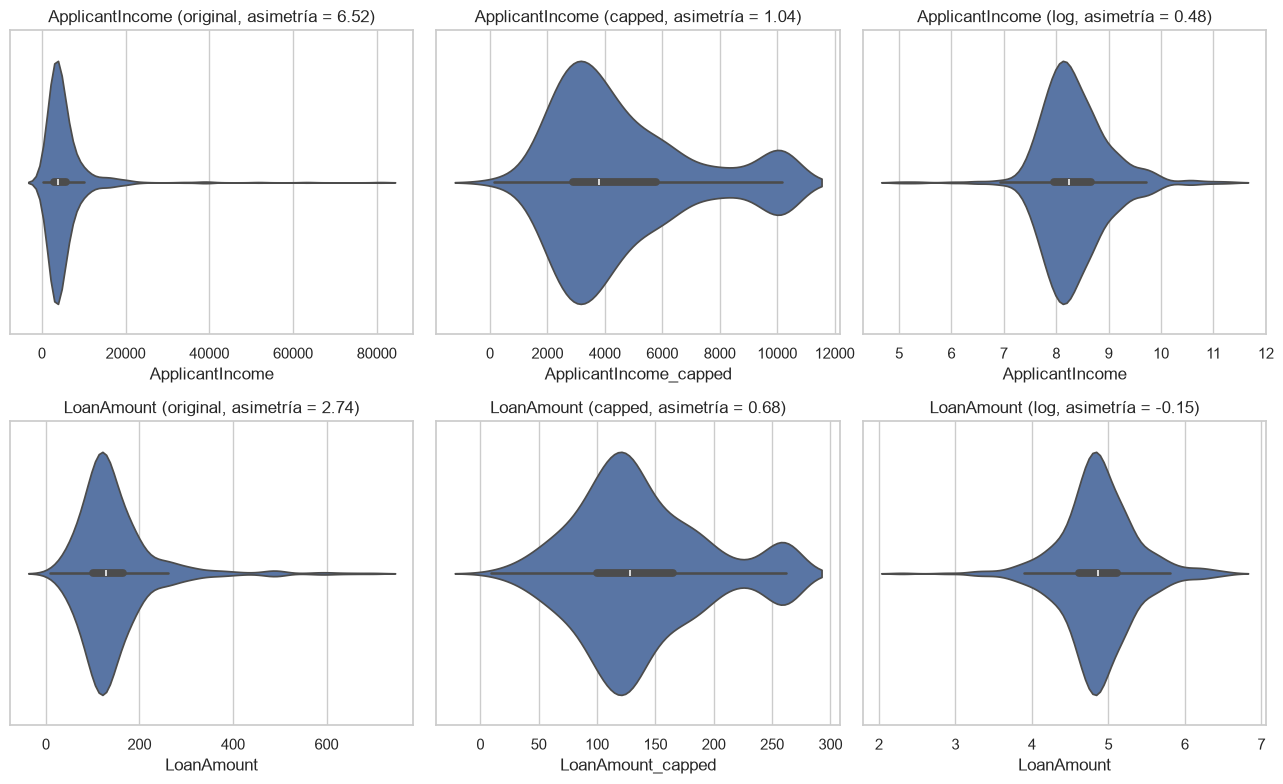

In [30]:
loan_amount_log = np.log1p(clean_loan["LoanAmount"])

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for row, (name, original, capped, logged) in enumerate([
    ("ApplicantIncome", income, clean_loan["ApplicantIncome_capped"], income_log),
    ("LoanAmount", clean_loan["LoanAmount"], clean_loan["LoanAmount_capped"], loan_amount_log),
]):
    for col, (label, series) in enumerate([("original", original), ("capped", capped), ("log", logged)]):
        sns.violinplot(x=series, ax=axes[row, col])
        axes[row, col].set_title(f"{name} ({label}, asimetría = {stats.skew(series):.2f})")
plt.tight_layout()
plt.show()

El capping reduce la asimetría de ~6.5 a ~1.0 — mejora notable, pero está lejos de la simetría. El log-transform la baja a ~0.5, más cerca de una distribución simétrica. La diferencia tiene una razón: el capping solo recorta los valores extremos, mientras que el log comprime toda la escala. La elección depende del objetivo: **capping** si se necesita seguir interpretando la variable en sus unidades originales (dólares) para reportes o comparaciones directas; **log-transform** si el objetivo es una distribución más simétrica para un análisis o modelo posterior, aceptando que la escala deja de ser directamente interpretable. En este taller usamos la versión con capping para las comparaciones de la siguiente sección, porque seguimos hablando en términos de ingreso real.

## 7. Relación con la variable target (`Loan_Status`)

Cerramos comparando las variables numéricas (incluyendo las tratadas y las derivadas) frente al estado de aprobación.

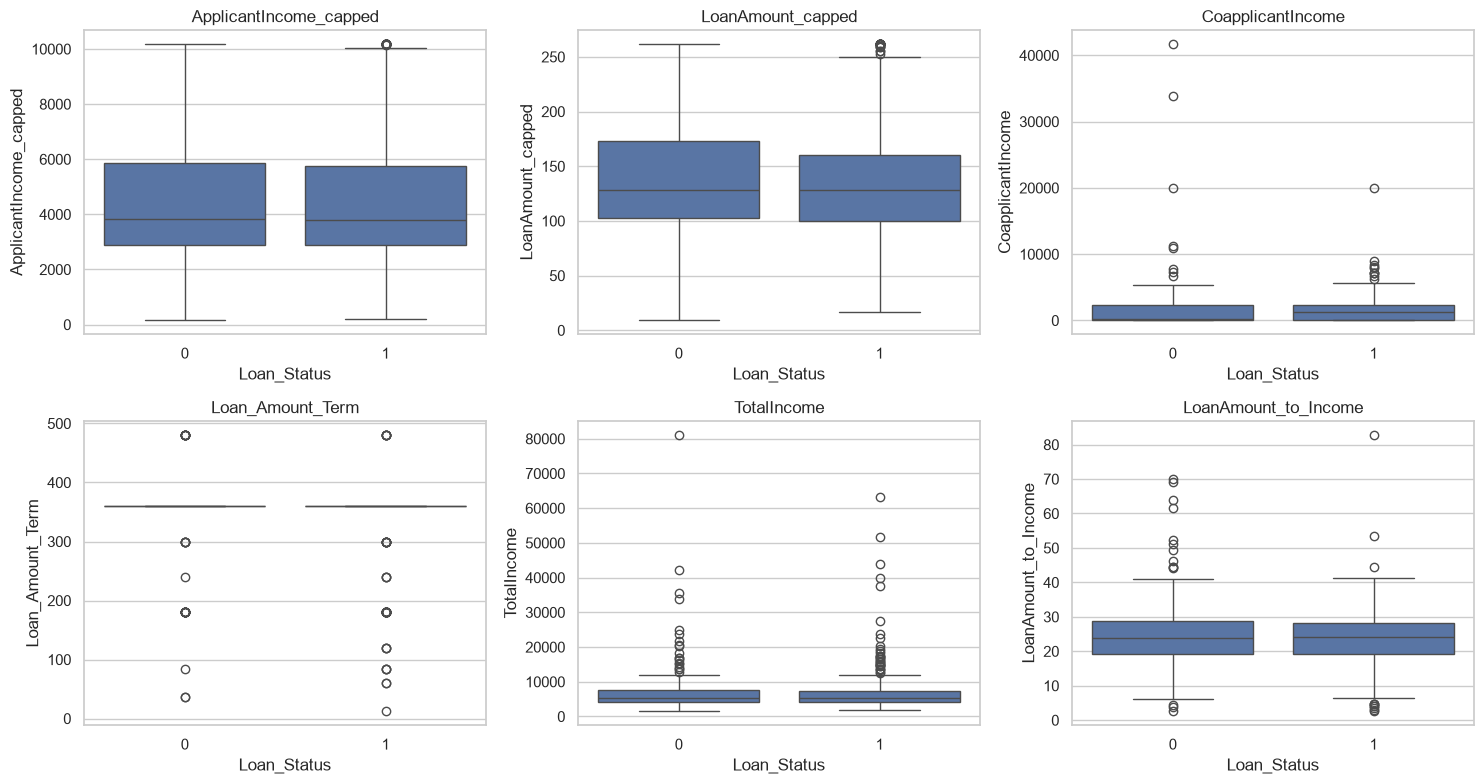

In [31]:
quant_relation_columns = ["ApplicantIncome_capped", "LoanAmount_capped", "CoapplicantIncome", "Loan_Amount_Term", "TotalIncome", "LoanAmount_to_Income"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for ax, column in zip(axes, quant_relation_columns):
    sns.boxplot(data=clean_loan, x="Loan_Status", y=column, ax=ax)
    ax.set_title(column)
plt.tight_layout()
plt.show()

In [32]:
clean_loan.groupby("Loan_Status")[quant_relation_columns].agg(["mean", "median"])

ApplicantIncome_capped         LoanAmount_capped         \
                              mean  median              mean median   
Loan_Status                                                           
0                         4618.736  3833.5           141.271  128.0   
1                         4616.373  3812.5           135.589  128.0   

            CoapplicantIncome         Loan_Amount_Term        TotalIncome  \
                         mean  median             mean median        mean   
Loan_Status                                                                 
0                    1877.807   268.0          344.562  360.0    7323.885   
1                    1504.516  1239.5          341.431  360.0    6888.585   

                    LoanAmount_to_Income          
             median                 mean  median  
Loan_Status                                       
0            5289.5               24.988  23.834  
1            5439.0               23.371  24.218

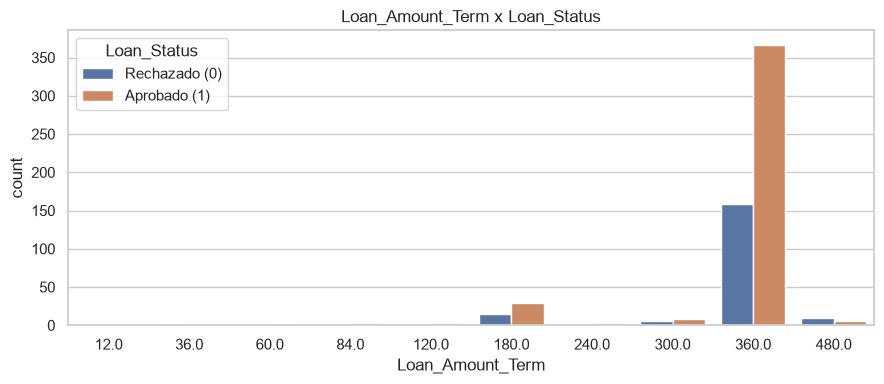

In [33]:
term_order = sorted(clean_loan["Loan_Amount_Term"].unique())

fig, ax = plt.subplots(figsize=(9, 4))
sns.countplot(data=clean_loan, x="Loan_Amount_Term", hue="Loan_Status", order=term_order, ax=ax)
ax.set_title("Loan_Amount_Term x Loan_Status")
ax.legend(title="Loan_Status", labels=["Rechazado (0)", "Aprobado (1)"])
plt.tight_layout()
plt.show()

**El hallazgo más contraintuitivo del taller:** `ApplicantIncome`, `LoanAmount`, `TotalIncome` y `LoanAmount_to_Income` apenas difieren entre aprobados y rechazados (medias y medianas muy cercanas entre los dos grupos — la carga de deuda, por ejemplo, es ~23.4 meses de ingreso en aprobados frente a ~25.0 en rechazados, una diferencia pequeña). Uno esperaría que un ingreso más alto o una carga de deuda menor facilite la aprobación, pero estos datos no lo muestran con fuerza — ni siquiera con la variable que construimos específicamente para capturar esa relación. No se puede concluir que el ingreso no importe en la realidad, solo que en este dataset no es la señal dominante que distingue aprobados de rechazados.

La excepción es `CoapplicantIncome`: su mediana es 268 entre los rechazados y 1,240 entre los aprobados — el 50.0% de los rechazados no tiene coaplicante, frente al 41.9% de los aprobados. Tener un coaplicante (y no tanto el monto de su ingreso) parece asociarse más con la aprobación que cualquiera de las variables de ingreso "principal". `Loan_Amount_Term` no muestra diferencia relevante entre grupos (dominada por el mismo valor de 360 meses en ambos).

In [34]:
(pd.crosstab(clean_loan["Credit_History"], clean_loan["Loan_Status"], normalize="index") * 100).round(1)

Loan_Status,0,1
Credit_History,,
0.0,92.1,7.9
1.0,21.0,79.0


`Credit_History` sí marca una diferencia enorme: ~79.0% de aprobación cuando vale 1, frente a ~7.9% cuando vale 0 — una brecha de ~71 puntos porcentuales, muchísimo mayor que cualquier diferencia vista con las variables cualitativas o cuantitativas anteriores. Es, con diferencia, la variable más asociada a `Loan_Status` en todo el dataset.

## 8. Preview: un primer modelo de clasificación

**Esto no es parte del taller de estadística descriptiva** — es un adelanto rápido de lo que viene en próximos cursos, aprovechando que el dataset original trae un segundo archivo (`test.csv`) pensado para eso. La idea es solo mostrar, en pocas líneas, cómo se ve entrenar y evaluar un modelo real usando el trabajo que ya hicieron: limpieza, variables derivadas y el hallazgo de que `Credit_History` es la señal dominante.

In [147]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Codificamos las dos categóricas binarias que usaremos; el resto de features ya son numéricas
clean_loan["Married_bin"] = clean_loan["Married"].map({"Yes": 1, "No": 0})
clean_loan["Education_bin"] = clean_loan["Education"].map({"Graduate": 1, "Not Graduate": 0})

features = ["Credit_History", "TotalIncome", "LoanAmount_to_Income", "Married_bin", "Education_bin"]
X = clean_loan[features]
y = clean_loan["Loan_Status"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
predictions = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, predictions):.1%}")
print(f"F1-score (clase 'Aprobado'): {f1_score(y_test, predictions):.1%}")
print(f"Baseline (predecir siempre 'aprobado'): {y_test.mean():.1%}")
print()
print(classification_report(y_test, predictions, target_names=["Rechazado", "Aprobado"]))

Accuracy: 85.4%
F1-score (clase 'Aprobado'): 90.3%
Baseline (predecir siempre 'aprobado'): 69.1%

              precision    recall  f1-score   support

   Rechazado       0.95      0.55      0.70        38
    Aprobado       0.83      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.77      0.80       123
weighted avg       0.87      0.85      0.84       123



Con 5 variables y sin ningún ajuste fino, el modelo llega a ~85.4% de accuracy y ~90.3% de F1-score para la clase "Aprobado", por encima del 69.1% que se lograría prediciendo siempre "aprobado" (la clase mayoritaria). Pero ese F1 alto solo cuenta la mitad de la historia: en el `classification_report` de abajo, la clase "Rechazado" tiene un F1 de apenas 0.70 (recall de solo 0.55, el modelo deja pasar casi la mitad de los rechazos reales) — el modelo rinde mucho mejor en la clase mayoritaria que en la minoritaria, un síntoma típico del desbalance de clases (68.7%/31.3%) que no se ve si solo miras accuracy o el F1 de una sola clase. No es una comparación rigurosa (para eso se necesita más — matriz de confusión, comparar contra otros modelos, manejar el desbalance explícitamente), pero confirma con un modelo real lo que ya habían visto de forma descriptiva: `Credit_History` termina siendo, por lejos, la variable con más peso.

In [36]:
pd.Series(model.coef_[0], index=features).sort_values(key=abs, ascending=False)

Credit_History          3.111e+00
Married_bin             4.874e-01
Education_bin           3.843e-01
LoanAmount_to_Income   -9.867e-03
TotalIncome            -1.857e-05
dtype: float64

### Comparando contra otro modelo: Random Forest

La regresión logística asume una relación lineal entre cada feature y el log-odds del target. Un Random Forest no tiene ese supuesto — puede capturar interacciones y relaciones no lineales. Lo entrenamos con el mismo split y las mismas features, para que la comparación sea justa.

In [148]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, rf_predictions):.1%}")
print(f"F1-score (clase 'Aprobado'): {f1_score(y_test, rf_predictions):.1%}")
print()
print(classification_report(y_test, rf_predictions, target_names=["Rechazado", "Aprobado"]))

Accuracy: 86.2%
F1-score (clase 'Aprobado'): 90.2%

              precision    recall  f1-score   support

   Rechazado       0.80      0.74      0.77        38
    Aprobado       0.89      0.92      0.90        85

    accuracy                           0.86       123
   macro avg       0.84      0.83      0.83       123
weighted avg       0.86      0.86      0.86       123



In [38]:
pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)

LoanAmount_to_Income    0.354
TotalIncome             0.354
Credit_History          0.256
Married_bin             0.019
Education_bin           0.017
dtype: float64

El Random Forest sube el accuracy a ~86.2% (vs. ~85.4% de la regresión logística) y, más importante, mejora notablemente la clase minoritaria: F1 de "Rechazado" sube de 0.70 a 0.77, con recall de 0.74 en vez de 0.55 — detecta muchos más rechazos reales sin sacrificar tanto la clase mayoritaria (F1 "Aprobado" prácticamente igual, ~90.2% vs. ~90.3%). El desbalance de clases sigue ahí, pero este modelo lo maneja mejor "de fábrica", sin que se lo hayamos pedido explícitamente.

Las importancias de features también cuentan una historia distinta a la de los coeficientes de la regresión logística: para el Random Forest, `LoanAmount_to_Income` y `TotalIncome` pesan tanto o más que `Credit_History` (a diferencia de la regresión logística, donde `Credit_History` dominaba con un coeficiente varias veces mayor). No es que un modelo esté "equivocado" y el otro "correcto" — reflejan formas distintas de usar la información: la regresión logística premia la señal lineal más fuerte, mientras que el Random Forest puede estar aprovechando interacciones entre las variables de ingreso que el modelo lineal no captura. Comparar estos dos ranking de importancia — y entender por qué difieren — es exactamente el tipo de pregunta que se profundiza en cursos de machine learning.

El coeficiente de `Credit_History` es varias veces más grande que el de cualquier otra variable — coherente con la brecha de ~71 puntos porcentuales que ya habían encontrado en la sección 4.

Como bonus, el dataset original incluye un segundo archivo, `test.csv`, pensado para que el modelo prediga sobre solicitudes que nunca vio. No trae la columna `Loan_Status` (es el set de la competencia de Analytics Vidhya sin etiquetas públicas), así que no podemos calcular su accuracy — pero sí podemos ver qué predice el modelo para esas solicitudes nuevas, aplicando exactamente la misma limpieza y las mismas variables derivadas que construimos para `train`.

In [149]:
loan_test = pd.read_csv("https://raw.githubusercontent.com/sahutkarsh/loan-prediction-analytics-vidhya/master/test.csv")

# Imputamos con las estadísticas del train (no las de test), la misma lógica de la sección 2
loan_test["Married"] = loan_test["Married"].fillna(loan["Married"].mode()[0])
loan_test["Credit_History"] = loan_test["Credit_History"].fillna(loan["Credit_History"].mode()[0])
loan_test["LoanAmount"] = loan_test["LoanAmount"].fillna(loan["LoanAmount"].median())

loan_test["TotalIncome"] = loan_test["ApplicantIncome"] + loan_test["CoapplicantIncome"]
loan_test["LoanAmount_to_Income"] = (loan_test["LoanAmount"] * 1000) / loan_test["TotalIncome"]
loan_test["Married_bin"] = loan_test["Married"].map({"Yes": 1, "No": 0})
loan_test["Education_bin"] = loan_test["Education"].map({"Graduate": 1, "Not Graduate": 0})

test_predictions = model.predict(loan_test[features])

pd.DataFrame({
    "Loan_ID": loan_test["Loan_ID"],
    "Predicción": pd.Series(test_predictions).map({0: "Rechazado", 1: "Aprobado"}),
}).head(10)

,Loan_ID,Predicción
0,LP001015,Aprobado
1,LP001022,Aprobado
2,LP001031,Aprobado
3,LP001035,Aprobado
4,LP001051,Aprobado
5,LP001054,Aprobado
6,LP001055,Aprobado
7,LP001056,Rechazado
8,LP001059,Aprobado
9,LP001067,Aprobado


Ya comparamos dos modelos, pero esto sigue siendo apenas la punta del iceberg: falta validar con más rigor (cross-validation, no un solo split), probar más modelos, ajustar hiperparámetros, manejar el desbalance de clases explícitamente (68.7%/31.3%), y decidir umbrales de decisión según el costo de cada tipo de error. Todo eso — y las pruebas de hipótesis para confirmar si las diferencias que encontraron en este taller son estadísticamente significativas o podrían deberse al azar — es contenido de los próximos cursos.

## Cierre

**Ideas clave:**

- La limpieza de datos no siempre implica eliminar filas: aquí todos los faltantes se resolvieron con imputación, pero la decisión de *cómo* imputar (moda, mediana, o verificar primero si la ausencia se relaciona con el target) sí varió por variable.
- Antes de imputar una variable con muchos faltantes, vale la pena revisar si esos faltantes se comportan distinto al resto respecto al target — `Credit_History` mostró que no era el caso, lo que justificó una imputación simple.
- Una variable derivada (`TotalIncome`, `LoanAmount_to_Income`) solo aporta si responde una pregunta que las originales no responden — aquí tenían sentido de negocio claro, aunque terminaron sin mostrar relación fuerte con el target.
- Detectar atípicos con IQR es solo el primer paso; tratarlos (capping vs. transformación log) es una decisión con trade-offs distintos según si necesitas conservar las unidades originales o priorizar simetría.
- El hallazgo más importante no fue el esperado: el ingreso (y las variables derivadas de él) casi no diferencia aprobados de rechazados, mientras que `Credit_History` domina por completo — un recordatorio de que la intuición de negocio hay que contrastarla con los datos, no asumirla. El modelo de la sección 8 confirmó lo mismo con un número real de accuracy, no solo con tablas descriptivas.

**Qué queda fuera a propósito:** este taller es de estadística *descriptiva*. No se prueba si estas diferencias son estadísticamente significativas (eso requiere pruebas de hipótesis) ni se construye un modelo de clasificación con rigor (la sección 8 fue solo un adelanto motivacional, sin validación cruzada ni comparación entre modelos) — eso es contenido de la sesión 6 en adelante.